In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Datasets**

In [2]:
#plant 1 generation data
gen1 = pd.read_csv("Plant_1_Generation_Data.csv")

#plant 1 weather sensor data
weather1 = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

In [3]:
print("Power generation data of plant 1")
gen1.head()

Power generation data of plant 1


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
print("Weather sensor data of plant 1")
weather1.head()

Weather sensor data of plant 1


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [5]:
# Convert both DATE_TIME columns to same format
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather1['DATE_TIME'] = pd.to_datetime(weather1['DATE_TIME'])

In [6]:
plant1_data= pd.merge(gen1, weather1, on='DATE_TIME')

In [7]:
plant1_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68774 entries, 0 to 68773
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68774 non-null  datetime64[ns]
 1   PLANT_ID_x           68774 non-null  int64         
 2   SOURCE_KEY_x         68774 non-null  object        
 3   DC_POWER             68774 non-null  float64       
 4   AC_POWER             68774 non-null  float64       
 5   DAILY_YIELD          68774 non-null  float64       
 6   TOTAL_YIELD          68774 non-null  float64       
 7   PLANT_ID_y           68774 non-null  int64         
 8   SOURCE_KEY_y         68774 non-null  object        
 9   AMBIENT_TEMPERATURE  68774 non-null  float64       
 10  MODULE_TEMPERATURE   68774 non-null  float64       
 11  IRRADIATION          68774 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(2), object(2)
memory usage: 6.3+ MB


In [8]:
plant1_data.head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


**Preprocessing Data**

In [9]:
#plant1_Extract useful time features

plant1_data['hour'] = plant1_data['DATE_TIME'].dt.hour
plant1_data['day'] = plant1_data['DATE_TIME'].dt.day
plant1_data['month'] = plant1_data['DATE_TIME'].dt.month

In [10]:
# Shuffle the entire DataFrame
plant1_data_shuffled = plant1_data.sample(frac=1, random_state=15).reset_index(drop=True)


In [11]:
# Features for prediction
features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'hour', 'month']

# Target variable (what we want to predict)
target = 'DC_POWER'

X = plant1_data_shuffled[features]
y = plant1_data_shuffled[target]

In [12]:
#Normalizing features (Not the target)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) 

# Convert back to DataFrame with original column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [13]:
X_scaled_df.head()

,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,month
0,-0.186543,0.304432,0.703001,-0.519785,-1.037792
1,0.493631,0.615434,0.683489,0.354519,-1.037792
2,0.930439,-0.466500,-0.769361,0.937389,-1.037792
3,0.222801,0.068169,-0.129217,0.645954,0.963585
4,-0.716217,-0.904364,-0.737508,-0.811219,-1.037792


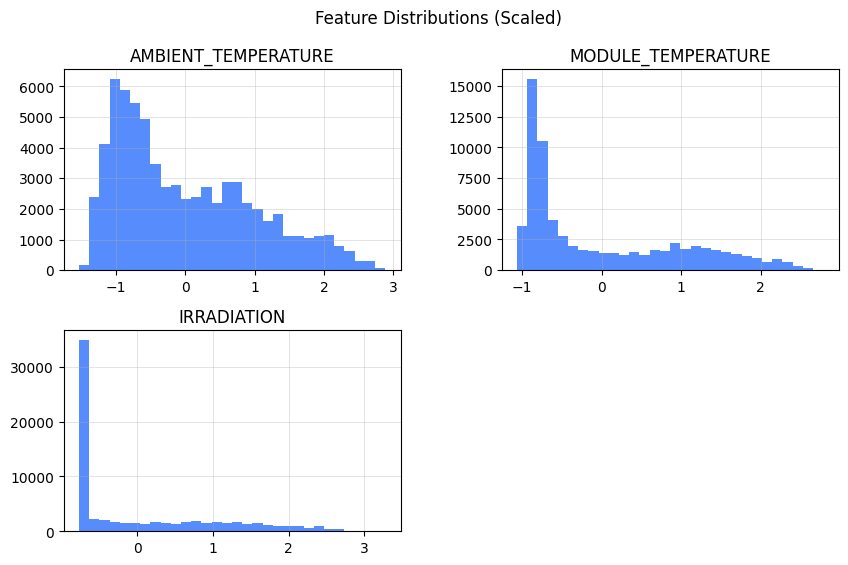

In [14]:
#Visualizing

import matplotlib.pyplot as plt

X_scaled_df[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].hist(bins=30, figsize=(10, 6))
plt.suptitle('Feature Distributions (Scaled)')
plt.show()

**Splitting and Training the Dataset**

In [15]:
# Splitting data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=15)

In [16]:
# Training with Linear Regresssion 

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Making Prediction**

In [17]:
y_pred = model.predict(X_test)

In [18]:
#Checking Accuracy

model.score(X_test, y_test)

0.9757163589367726

**Evaluation of the Model**

In [19]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R-squared (R2 Score):", r2)

R-squared (R2 Score): 0.9757163589367726


**Visualizing the Prediction **

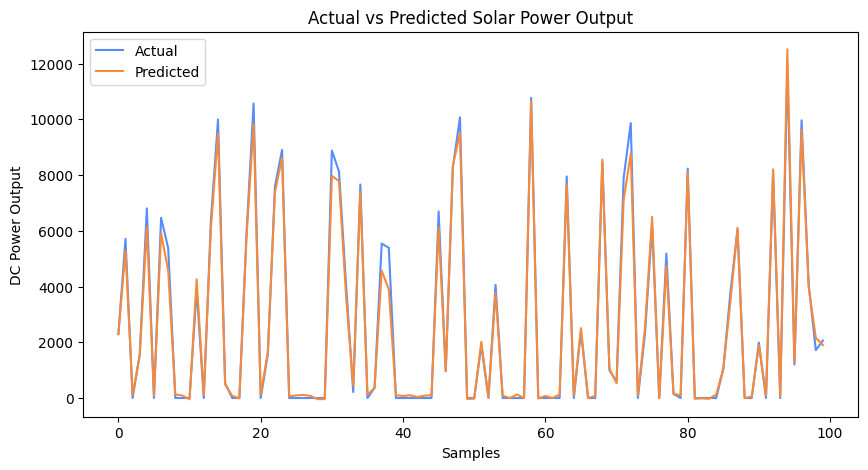

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.xlabel('Samples')
plt.ylabel('DC Power Output')
plt.legend()
plt.title('Actual vs Predicted Solar Power Output')
plt.show()